In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, RobertaModel, RobertaTokenizer
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import DBSCAN
from sklearn.utils.class_weight import compute_class_weight
import openai
import json
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'C++']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 2]
leetcode_questions_df = leetcode_questions_df.drop_duplicates(subset=['question_code'])

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17227 entries, 64 to 61813
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            17227 non-null  object 
 1   country                             17227 non-null  object 
 2   contest_url                         17227 non-null  object 
 3   num_of_contest                      17227 non-null  int64  
 4   is_weekly                           17227 non-null  bool   
 5   rank                                17227 non-null  int64  
 6   score                               17227 non-null  int64  
 7   question_number                     17227 non-null  int64  
 8   question_language                   17227 non-null  object 
 9   question_code                       17227 non-null  object 
 10  number_of_lines                     17227 non-null  int64  
 11  names_set                           17227 non

<Axes: >

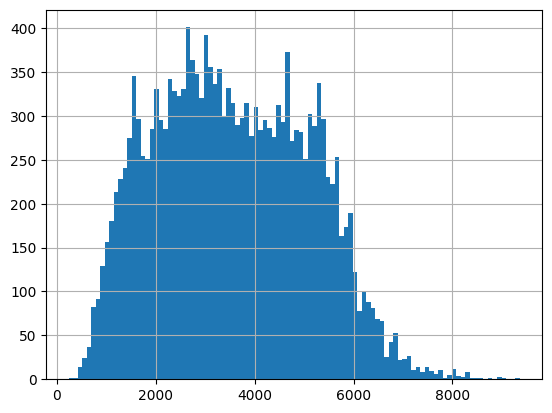

In [ ]:
leetcode_questions_df.contest_finish_time_total_seconds.hist(bins=100)

In [ ]:
# Define rank thresholds
percantage = 10

high_rank_threshold = leetcode_questions_df['contest_finish_time_total_seconds'].quantile(percantage/100)
low_rank_threshold = leetcode_questions_df['contest_finish_time_total_seconds'].quantile(1 - percantage/100)


leetcode_questions_df["experienced_programmer"] = leetcode_questions_df["contest_finish_time_total_seconds"] <= low_rank_threshold


high_rank_df = leetcode_questions_df[leetcode_questions_df["contest_finish_time_total_seconds"] < high_rank_threshold]
low_rank_df = leetcode_questions_df[leetcode_questions_df["contest_finish_time_total_seconds"] > low_rank_threshold]


filtered_df = pd.concat([high_rank_df, low_rank_df])

filtered_df.reset_index(drop=True, inplace=True)

filtered_df["experienced_programmer"].value_counts()

,count
experienced_programmer,
True,1720
False,1720


In [ ]:
leetcode_questions_df = filtered_df

In [ ]:
leetcode_questions_df.describe()

,num_of_contest,rank,score,question_number,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,...,function_density,loop_density,condition_density,comment_tokens_density,contest_finish_time_total_seconds,question_finish_time_total_seconds,time_spent_per_question,global_rank_percentile,question_code_length,num_contests_participated
count,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,...,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000
mean,285.179360,541.034593,16.051163,3.378779,54.972674,47.428198,23.945349,3.232267,3.758430,4.882849,...,0.049646,0.089641,0.108505,0.088174,3692.917151,2423.980814,1214.640407,0.041852,1585.792151,7.898547
std,124.726992,382.172368,2.953108,0.485153,52.781271,41.881027,22.815809,9.988877,4.331369,5.935727,...,0.040750,0.071999,0.075578,0.157392,2563.643015,1779.336745,1170.629504,0.087554,1881.008566,6.687682
min,117.000000,1.000000,8.000000,3.000000,6.000000,10.000000,4.000000,1.000000,0.000000,0.000000,...,0.007874,0.000000,0.000000,0.000000,237.000000,160.000000,0.000000,0.000001,108.000000,1.000000
25%,124.000000,140.000000,12.000000,3.000000,31.000000,30.000000,15.000000,1.000000,2.000000,2.000000,...,0.028571,0.039331,0.052632,0.000000,1207.000000,951.000000,365.000000,0.001832,840.000000,2.000000
50%,374.000000,578.000000,18.000000,3.000000,43.000000,36.000000,19.000000,1.000000,3.000000,4.000000,...,0.038462,0.080000,0.096154,0.000000,3568.000000,1440.000000,724.000000,0.008877,1204.000000,6.000000
75%,384.000000,867.000000,18.000000,4.000000,61.000000,47.250000,25.000000,2.000000,5.000000,6.000000,...,0.058824,0.120000,0.151515,0.128205,6031.000000,4396.500000,1878.250000,0.038555,1707.250000,11.000000
max,390.000000,1223.000000,20.000000,4.000000,793.000000,450.000000,291.000000,135.000000,69.000000,108.000000,...,0.589041,1.066667,0.538462,0.877551,9359.000000,5399.000000,5238.000000,0.951969,26867.000000,29.000000


In [ ]:
X=leetcode_questions_df.drop('experienced_programmer',axis=1)
Y=leetcode_questions_df.experienced_programmer.astype(int)

In [ ]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.question_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [ ]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

In [ ]:
df = pd.concat([X_train_text, y_train], axis=1)

system_prompt = "You are a code reviewer. Determine if the following code was written by an experienced programmer. Respond with 'Yes' or 'No'."

conversations = []

for _, row in df.iterrows():
    user_message = f"Here is the code:\n\n{row['question_code']}\n\nIs this written by an experienced programmer?"
    assistant_response = "Yes" if row["experienced_programmer"] == 1 else "No"

    conversation = {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message},
            {"role": "assistant", "content": assistant_response}
        ]
    }
    conversations.append(conversation)

with open("training_data.jsonl", "w") as f:
    for convo in conversations:
        f.write(json.dumps(convo) + "\n")


In [ ]:
df = pd.concat([X_valid_text, y_valid], axis=1)

system_prompt = "You are a code reviewer. Determine if the following code was written by an experienced programmer. Respond with 'Yes' or 'No'."

conversations = []

for _, row in df.iterrows():
    user_message = f"Here is the code:\n\n{row['question_code']}\n\nIs this written by an experienced programmer?"
    assistant_response = "Yes" if row["experienced_programmer"] == 1 else "No"

    conversation = {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message},
            {"role": "assistant", "content": assistant_response}
        ]
    }
    conversations.append(conversation)

# Write the conversations to a JSONL file
with open("validation_data.jsonl", "w") as f:
    for convo in conversations:
        f.write(json.dumps(convo) + "\n")

# Finetuned GPT 4 nano

In [ ]:
MODEL_NAME = "ft:gpt-4.1-nano-2025-04-14:personal:cplusplus-experience:BdDRm6Vy"
API_KEY = ""

client = openai.OpenAI(api_key=API_KEY)

In [ ]:
def get_finetuned_llm_prediction(code):
  response = client.chat.completions.create(
      model=MODEL_NAME,
      messages=[
                  {"role": "system", "content": "You are a code reviewer. Determine if the following code was written by an experienced programmer. Respond with 'Yes' or 'No'."},
                  {"role": "user", "content": f"Here is the code:\n\n{code}\n\nIs this written by an experienced programmer?"}
               ],
  )

  return {"Yes": 1, "No": 0}[response.choices[0].message.content]

In [ ]:
y_test_llm = X_test_text.apply(get_finetuned_llm_prediction)

              precision    recall  f1-score   support

    low_rank       0.85      0.88      0.86       344
   high_rank       0.87      0.85      0.86       344

    accuracy                           0.86       688
   macro avg       0.86      0.86      0.86       688
weighted avg       0.86      0.86      0.86       688

f1_score_macro :  0.8618949717176285
f1_score_weighted :  0.8618949717176284


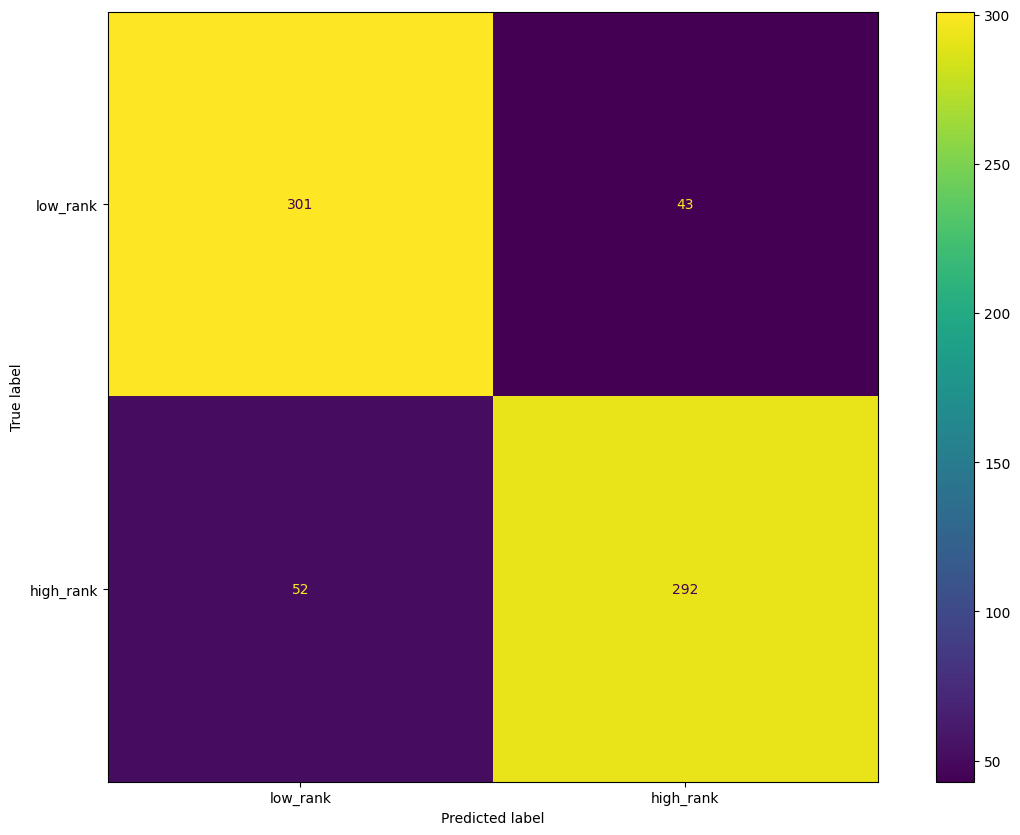

In [ ]:
print(classification_report(y_test, y_test_llm, target_names=['low_rank','high_rank']))

print("f1_score_macro : ",f1_score(y_test, y_test_llm, average='macro'))
print("f1_score_weighted : ",f1_score(y_test, y_test_llm, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_llm), display_labels=['low_rank','high_rank'])

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

# Error Analysis

In [ ]:
test_df = leetcode_questions_df.loc[X_test_text.index]

In [ ]:
test_df['correct'] = y_test_llm == y_test

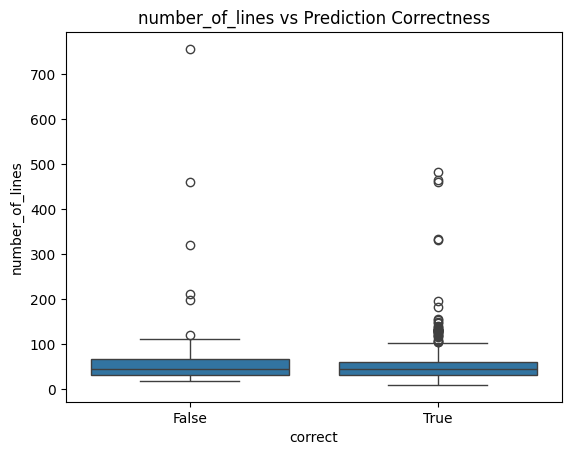

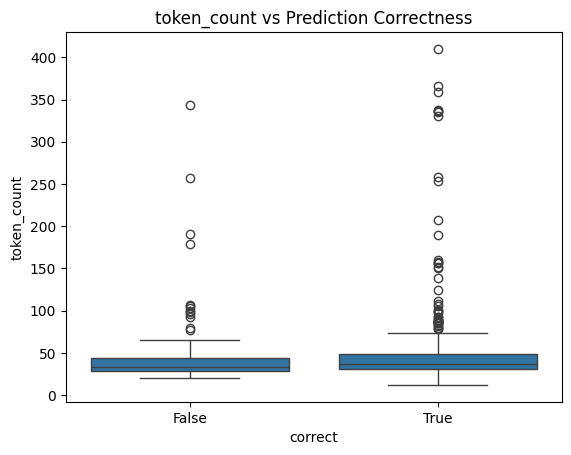

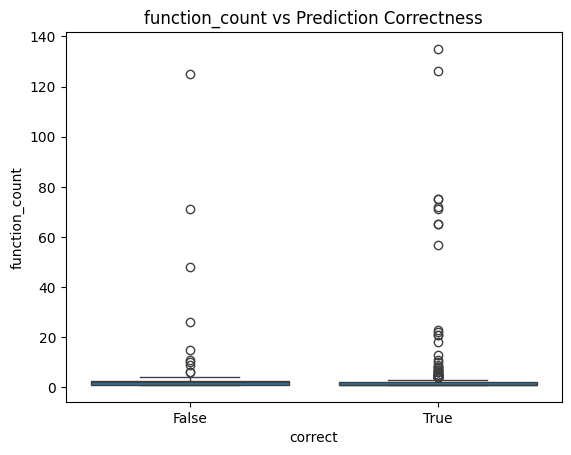

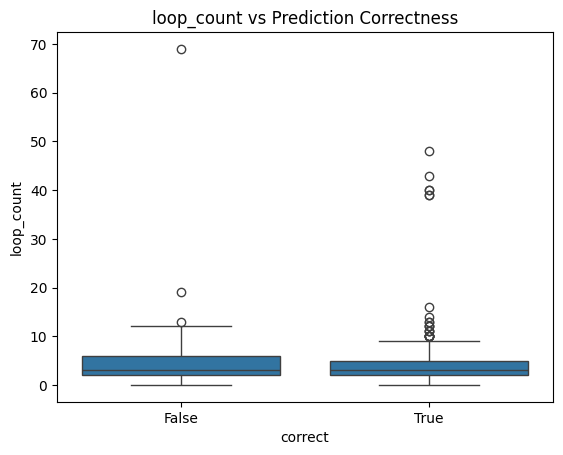

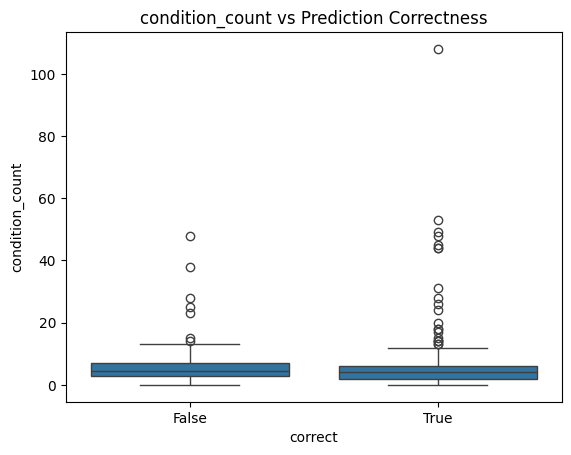

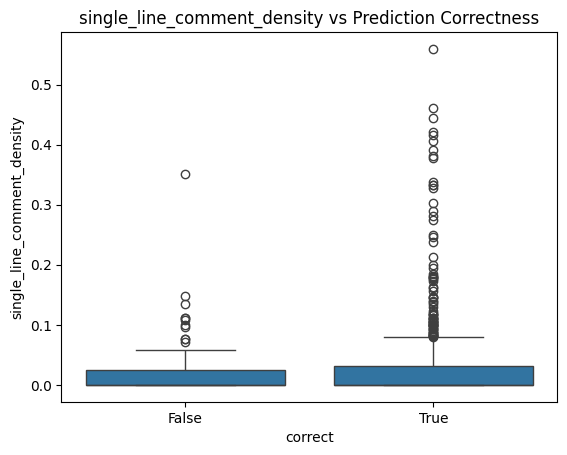

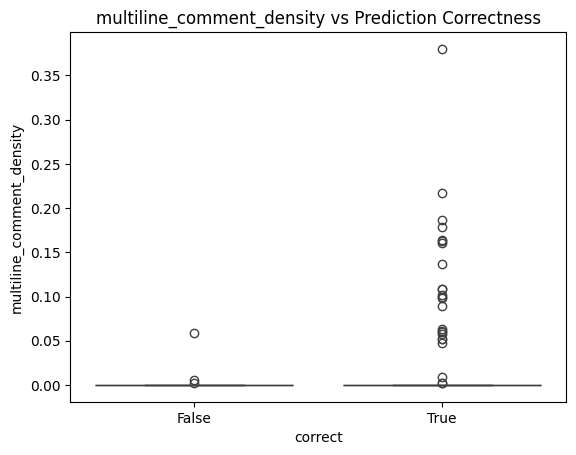

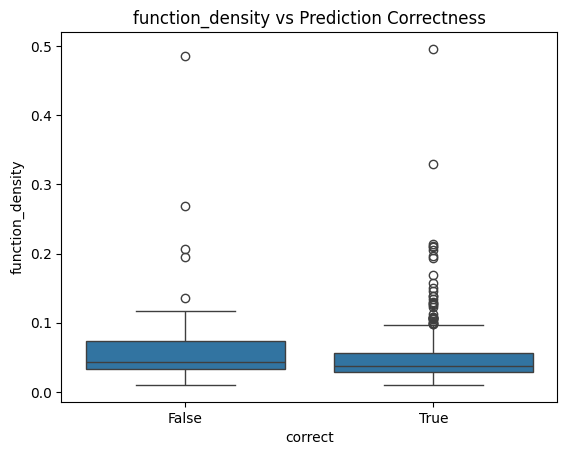

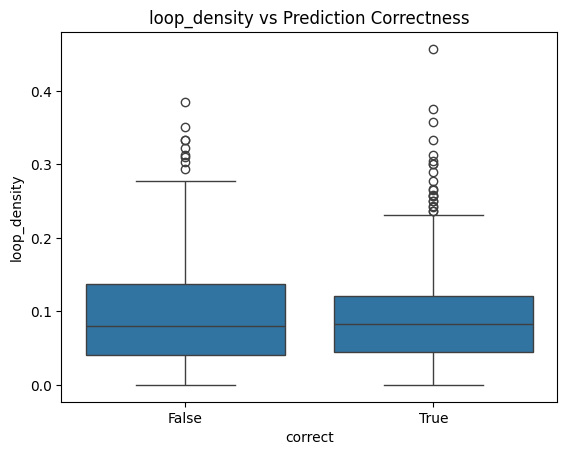

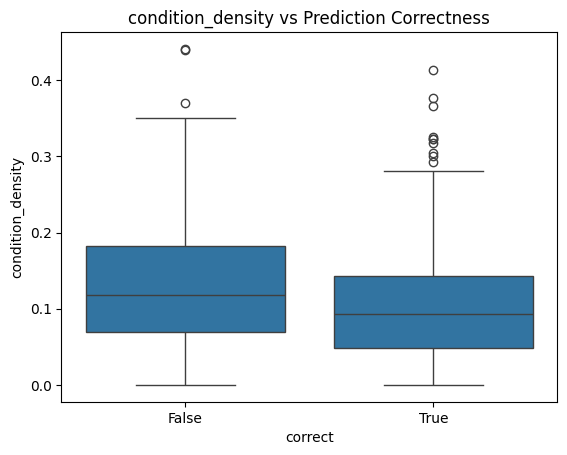

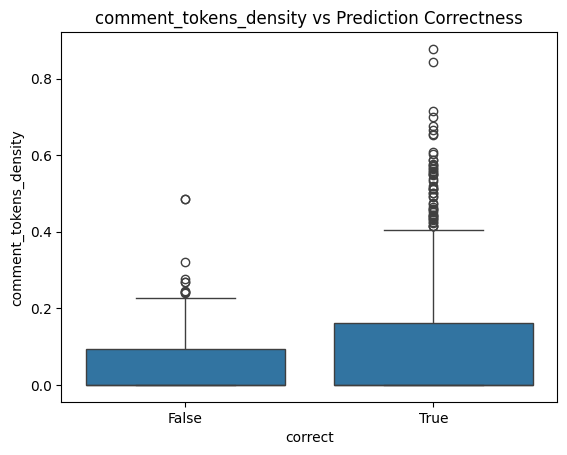

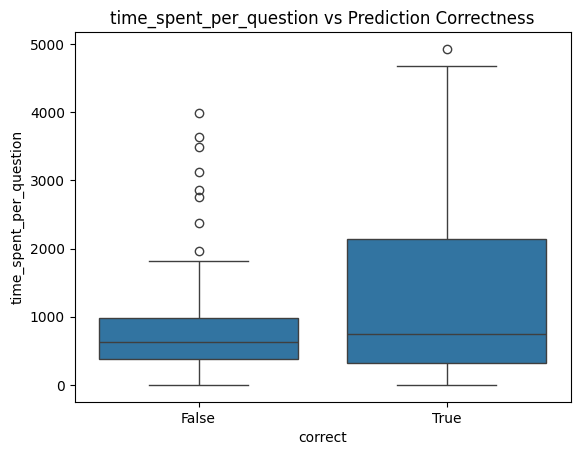

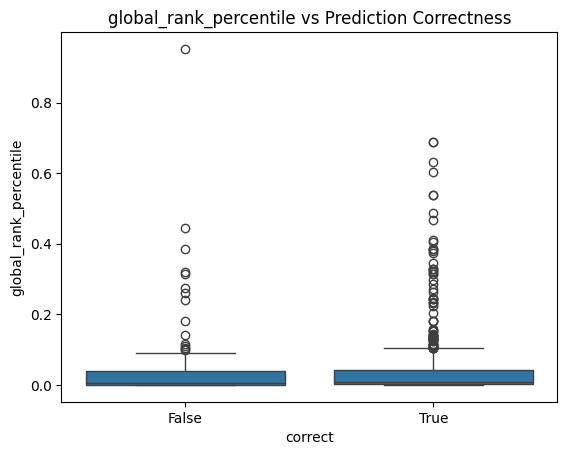

In [ ]:
features_to_plot = [
    'number_of_lines', 'token_count', 'function_count',
    'loop_count', 'condition_count',
    'single_line_comment_density', 'multiline_comment_density',
    'function_density', 'loop_density', 'condition_density',
    'comment_tokens_density', 'time_spent_per_question',
    'global_rank_percentile'
]

for col in features_to_plot:
    sns.boxplot(x='correct', y=col, data=test_df)
    plt.title(f'{col} vs Prediction Correctness')
    plt.show()

In [ ]:
test_df.groupby('correct')[features_to_plot].mean().T.sort_values(by=False, ascending=False)

correct,False,True
time_spent_per_question,817.088235,1321.725256
number_of_lines,66.509804,52.994881
token_count,47.745098,47.822526
condition_count,6.088235,4.901024
function_count,4.754902,3.247440
loop_count,4.627451,3.890785
condition_density,0.132770,0.104015
loop_density,0.102924,0.089356
function_density,0.062022,0.048140
comment_tokens_density,0.061977,0.101986


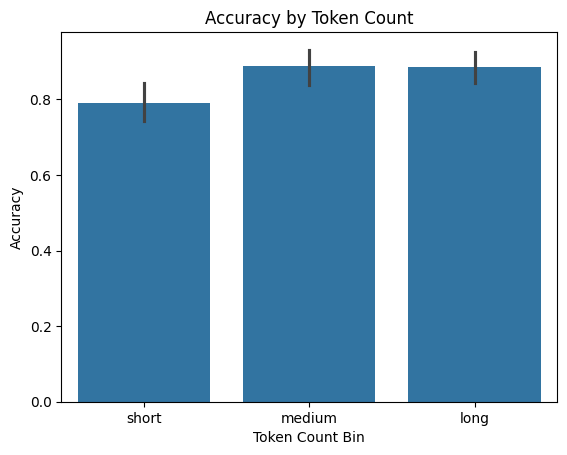

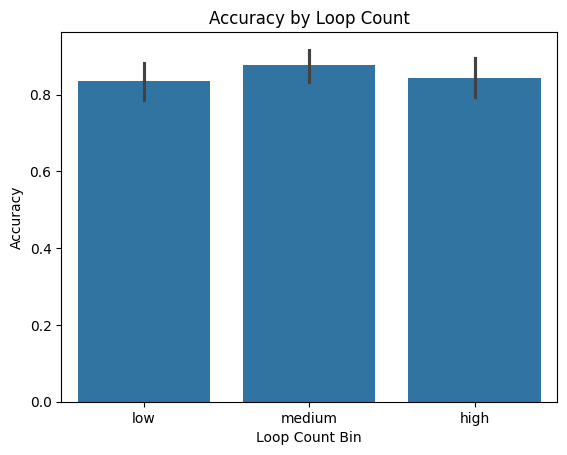

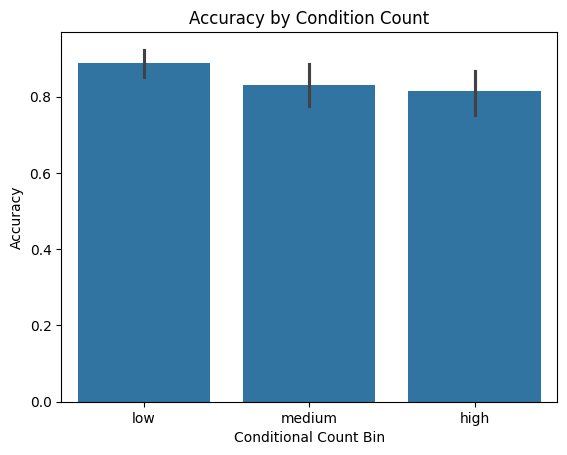

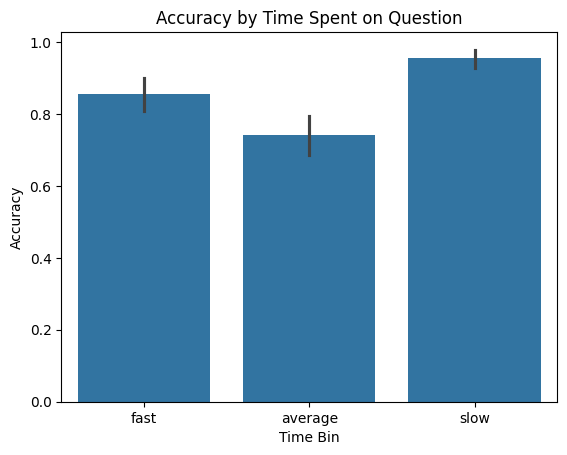

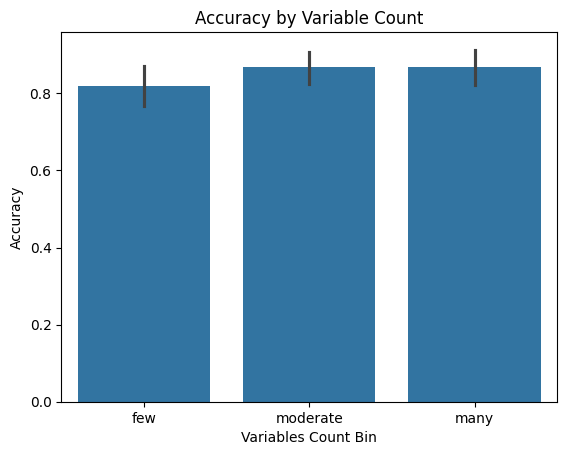

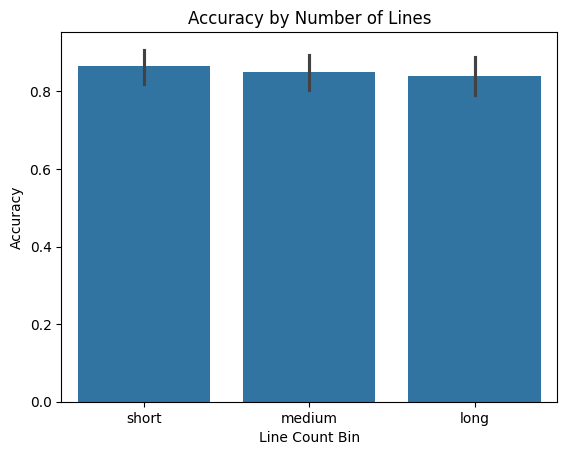

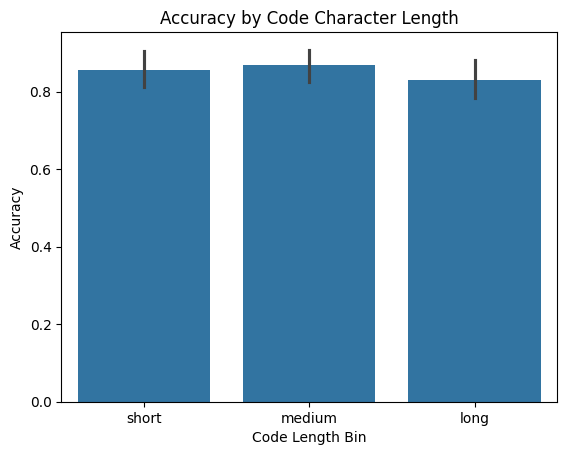

In [ ]:
# --------------------------
# Binning Continuous Features
# --------------------------
test_df['token_bin'] = pd.qcut(test_df['token_count'], 3, labels=["short", "medium", "long"])
test_df['line_bin'] = pd.qcut(test_df['number_of_lines'], 3, labels=["short", "medium", "long"])
test_df['loop_bin'] = pd.qcut(test_df['loop_count'], 3, labels=["low", "medium", "high"])
test_df['cond_bin'] = pd.qcut(test_df['condition_count'], 3, labels=["low", "medium", "high"])
test_df['time_bin'] = pd.qcut(test_df['time_spent_per_question'], 3, labels=["fast", "average", "slow"])
test_df['var_bin'] = pd.qcut(test_df['variables_count'], 3, labels=["few", "moderate", "many"])
test_df['code_len_bin'] = pd.qcut(test_df['question_code_length'], 3, labels=["short", "medium", "long"])

# --------------------------
# 1. Barplot: Accuracy by Token Count Bin
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='token_bin', y='correct')
plt.title("Accuracy by Token Count")
plt.xlabel("Token Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 2. Barplot: Accuracy by Loop Count Bin
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='loop_bin', y='correct')
plt.title("Accuracy by Loop Count")
plt.xlabel("Loop Count Bin")
plt.ylabel("Accuracy")
plt.show()


# --------------------------
# 3. Barplot: Conditional Count
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='cond_bin', y='correct')
plt.title("Accuracy by Condition Count")
plt.xlabel("Conditional Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 4. Barplot: Time Spent per Question
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='time_bin', y='correct')
plt.title("Accuracy by Time Spent on Question")
plt.xlabel("Time Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 5. Barplot: Variable Count
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='var_bin', y='correct')
plt.title("Accuracy by Variable Count")
plt.xlabel("Variables Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 6. Barplot: Number of Lines
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='line_bin', y='correct')
plt.title("Accuracy by Number of Lines")
plt.xlabel("Line Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 7. Barplot: Code Character Length
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='code_len_bin', y='correct')
plt.title("Accuracy by Code Character Length")
plt.xlabel("Code Length Bin")
plt.ylabel("Accuracy")
plt.show()


In [ ]:
test_df.to_csv("output.csv")